# 30. 지금 피처로 낼 수 있는 최대 성능

## Overview

분석 트랙이 29번에서 닫히고 `model/` 패키지로 옮겼습니다. 이 문서는
**옮긴 코드 위에서 "더 짤 것이 남았나"를 마지막으로 확인**합니다.

**피처는 안 늘립니다.** 16·21·25·26·27번에서 출하량·기상을 붙였다 뗐고,
결론은 "묶으면 보이고 쪼개면 안 보인다"였습니다. 지금 있는 21개로 봅니다.

**모델 용량도 안 건드립니다.** 05번에서 하이퍼파라미터를 훑었고 유효한 건
`learning_rate` 뿐이었습니다. 깊이·잎 수를 다시 돌리는 건 이미 반증된
실험입니다.

## 그럼 무엇을 보나: 확률의 품질

**한 번도 안 잰 축이 하나 있습니다.** 운영 규칙이 `|P(오름) - 0.5| >= 0.20`
이라 **확률이 숫자로서 맞아야** 임계값이 옳은 날을 고릅니다. 그런데
지금까지는 적중률(맞았나 틀렸나)만 봤지 **확률이 잘 보정됐는지**는
본 적이 없습니다.

모델이 "70% 오른다"고 한 날이 실제로 70% 오르는지, 아니면 실제로는
55% 인데 자신만만한 건지 — 후자라면 임계값이 헛것을 고르는 것입니다.

## 후보

| | 후보 | 노리는 것 |
|---|---|---|
| A | 채택안 (기준선) | 비교 기준 |
| B | 시드 앙상블 | 확률의 분산을 줄인다 |
| C | 등온 보정 | 확률을 실제 빈도에 맞춘다 |
| D | 시그모이드 보정 | 위와 같되 더 부드럽게 |
| E | RandomForest | 다른 계열 |
| F | ExtraTrees | 더 무작위한 계열 |
| G | 로지스틱 회귀 | 선형 기준선 |
| H | 혼합 앙상블 | 계열 다양성 |
| I | 분기 재학습 | 더 신선한 데이터 |

## 판정 규칙 (결과를 보기 전에 정합니다)

1. **노이즈 플로어를 먼저 잰다.** 그보다 작은 차이는 발견이 아니다.
2. **커버리지를 맞춰 비교한다**(21번 교훈). 고정 임계값으로 재면
   확신도 분포가 다른 모델끼리 표본 크기가 달라져 비교가 깨진다.
3. **적중률만으로 채택하지 않는다.** 폴드별로 일관돼야 한다(27번 교훈).

## 목차

1. 준비와 노이즈 플로어
2. 후보 정의
3. 전부 돌리기
4. 확률이 믿을 만한가: 신뢰도 곡선
5. 커버리지를 맞춘 비교
6. 폴드별 안정성
7. 돈으로 환산하면
8. 정리

## 1. 준비와 노이즈 플로어

`model/` 패키지를 그대로 씁니다. 노트북에 복붙하지 않는 게 요점입니다 —
`--check` 로 15·19번 재현이 확인된 코드입니다.

In [1]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from sklearn.ensemble import (ExtraTreesClassifier, HistGradientBoostingClassifier,
                              RandomForestClassifier)
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import model as M
from model import config as CFG
from model.features import FEATURES, categorical_indices
from model.metrics import score, score_at_coverage

warnings.filterwarnings("ignore")
_av = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _av:
        plt.rcParams["font.family"] = _f
        break
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})
plt.rcParams["axes.unicode_minus"] = False

df = M.load_mart()
GROUPS = M.item_groups(df)
FEAT = M.build_features(df, GROUPS["전체"])
대상 = GROUPS["운영 대상"]           # 정체 3품목 뺀 16품목
CAT = categorical_indices(FEATURES)
print(f"{len(GROUPS['전체'])}품목 {len(FEAT):,}행 · 평가 대상 {len(대상)}품목")

19품목 23,945행 · 평가 대상 16품목


In [2]:
t0 = time.time()
nf = M.noise_floor(FEAT, 대상)
FLOOR = {c: nf[c].max() - nf[c].min()
         for c in ("적중률 %", "확신한 날 적중률 %", "창고비 한도 %")}
display(nf.round(3))
print("노이즈 플로어 (무의미한 피처 4개를 넣고 값을 5번 흔든 폭):")
for k, v in FLOOR.items():
    print(f"  {k}: {v:.2f}%p")
print(f"\n이보다 작은 차이는 발견이 아닙니다. ({time.time()-t0:.0f}초)")

,seed,적중률 %,확신한 날 적중률 %,확신한 날 비율 %,더 받은 돈 %,창고비 한도 %,품목당 연 창고행,브라이어 점수,로그손실
0,0,63.252,73.477,31.498,2.665,13.973,45.604,0.226,0.645
1,1,62.996,73.677,31.681,2.677,14.013,45.674,0.227,0.645
2,2,63.128,73.358,31.769,2.682,14.009,45.779,0.226,0.644
3,3,62.696,73.913,31.828,2.737,14.261,45.884,0.226,0.645
4,4,63.069,73.908,31.849,2.664,13.796,46.164,0.226,0.644


노이즈 플로어 (무의미한 피처 4개를 넣고 값을 5번 흔든 폭):
  적중률 %: 0.56%p
  확신한 날 적중률 %: 0.56%p
  창고비 한도 %: 0.47%p

이보다 작은 차이는 발견이 아닙니다. (61초)


## 2. 후보 정의

각 후보는 `(학습셋, 평가셋, 쓸 컬럼)` 을 받아 **오를 확률**을 돌려주는
함수 하나로 표현합니다. 이렇게 두면 폴드 루프를 한 벌만 두고 후보를
갈아 끼울 수 있습니다.

**보정에 쓸 검증셋은 시간순으로 뗍니다.** 무작위로 떼면 미래가 섞입니다.

In [3]:
def hgb(**kw):
    p = {**CFG.PARAMS, **kw}
    return HistGradientBoostingClassifier(
        early_stopping=False, random_state=CFG.RANDOM_STATE,
        categorical_features=CAT, **p)


def A_기준선(tr, te, use):
    return hgb().fit(tr[use], tr.오름).predict_proba(te[use])[:, 1]


def B_시드앙상블(tr, te, use, n=5):
    # max_features 를 1 미만으로 둬야 시드가 실제로 다른 모델을 만든다.
    # 기본값(1.0)이면 학습이 결정적이라 시드를 바꿔도 결과가 똑같다(교훈 7).
    ps = []
    for s in range(n):
        m = HistGradientBoostingClassifier(
            early_stopping=False, random_state=s, max_features=0.8,
            categorical_features=CAT, **CFG.PARAMS)
        ps.append(m.fit(tr[use], tr.오름).predict_proba(te[use])[:, 1])
    return np.mean(ps, axis=0)


def _시간순분할(tr, ratio=0.2):
    # 학습셋 끝쪽 ratio 를 보정용으로 뗀다. 날짜 기준이라 미래가 안 섞인다.
    cut = tr.price_date.quantile(1 - ratio)
    return tr[tr.price_date <= cut], tr[tr.price_date > cut]


def _보정(tr, te, use, method):
    fit, cal = _시간순분할(tr)
    base = hgb().fit(fit[use], fit.오름)
    p_cal = base.predict_proba(cal[use])[:, 1]
    p_te = base.predict_proba(te[use])[:, 1]
    if method == "isotonic":
        c = IsotonicRegression(out_of_bounds="clip").fit(p_cal, cal.오름.astype(int))
        return np.clip(c.predict(p_te), 1e-6, 1 - 1e-6)
    c = LogisticRegression().fit(p_cal.reshape(-1, 1), cal.오름.astype(int))
    return c.predict_proba(p_te.reshape(-1, 1))[:, 1]


def C_등온보정(tr, te, use):
    return _보정(tr, te, use, "isotonic")


def D_시그모이드보정(tr, te, use):
    return _보정(tr, te, use, "sigmoid")


def E_랜덤포레스트(tr, te, use):
    m = RandomForestClassifier(n_estimators=400, min_samples_leaf=21,
                               n_jobs=-1, random_state=CFG.RANDOM_STATE)
    return m.fit(tr[use], tr.오름).predict_proba(te[use])[:, 1]


def F_엑스트라트리(tr, te, use):
    m = ExtraTreesClassifier(n_estimators=400, min_samples_leaf=21,
                             n_jobs=-1, random_state=CFG.RANDOM_STATE)
    return m.fit(tr[use], tr.오름).predict_proba(te[use])[:, 1]


def G_로지스틱(tr, te, use):
    # 선형 모델은 NaN 을 못 받고 스케일에 민감해 대치·표준화가 필요하다.
    m = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                      LogisticRegression(max_iter=2000, C=0.1))
    return m.fit(tr[use], tr.오름).predict_proba(te[use])[:, 1]


def H_혼합앙상블(tr, te, use):
    return np.mean([A_기준선(tr, te, use), E_랜덤포레스트(tr, te, use),
                    F_엑스트라트리(tr, te, use)], axis=0)


후보 = {
    "A 채택안": A_기준선, "B 시드 앙상블": B_시드앙상블,
    "C 등온 보정": C_등온보정, "D 시그모이드 보정": D_시그모이드보정,
    "E 랜덤포레스트": E_랜덤포레스트, "F 엑스트라트리": F_엑스트라트리,
    "G 로지스틱": G_로지스틱, "H 혼합 앙상블": H_혼합앙상블,
}
print(f"후보 {len(후보) + 1}개 (I 분기 재학습은 폴드 루프가 달라 따로 정의)")

후보 9개 (I 분기 재학습은 폴드 루프가 달라 따로 정의)


## 3. 전부 돌리기

폴드 루프는 `model.walk_forward` 와 같은 규칙입니다: **폴드 시작 이전
데이터로만 학습하고, 학습 끝과 평가 시작 사이에 엠바고(10.5일)를 둡니다.**

In [4]:
def 돌리기(fn, eval_items=None, use=None, refit="fold"):
    # refit="fold"    폴드당 1회 학습 (기본)
    # refit="quarter" 폴드 안에서 분기마다 다시 학습 (후보 I)
    eval_items = eval_items or 대상
    use = list(use or FEATURES)
    out = []
    for s, e in CFG.FOLDS:
        s, e = pd.Timestamp(s), pd.Timestamp(e)
        te_all = FEAT[(FEAT.price_date >= s) & (FEAT.price_date <= e)
                      & (FEAT.item.isin(eval_items))]
        if te_all.empty:
            continue
        if refit == "fold":
            chunks = [(s, e)]
        else:
            starts = pd.date_range(s, e, freq="QS")
            chunks = [(a, min(a + pd.offsets.QuarterEnd(0), e)) for a in starts]
        for cs, ce in chunks:
            tr = FEAT[FEAT.price_date < cs - CFG.EMBARGO]
            te = te_all[(te_all.price_date >= cs) & (te_all.price_date <= ce)]
            if tr.empty or te.empty:
                continue
            t = te[["item", "price_date", "오름", "price_kg_avg", "미래가격"]].copy()
            t["오를확률"] = fn(tr, te, use)
            t["fold"] = s.strftime("%Y-%m")
            out.append(t)
    r = pd.concat(out).reset_index(drop=True)
    r["방향맞음"] = (r.오를확률 > 0.5) == r.오름
    r["확신도"] = (r.오를확률 - 0.5).abs()
    return r


t0 = time.time()
결과 = {}
for name, fn in 후보.items():
    t1 = time.time()
    결과[name] = 돌리기(fn)
    print(f"  {name:<14} {time.time()-t1:5.0f}초")
결과["I 분기 재학습"] = 돌리기(A_기준선, refit="quarter")
print(f"  {'I 분기 재학습':<14} 완료")
print(f"\n총 {time.time()-t0:.0f}초")

  A 채택안             12초


  B 시드 앙상블          62초


  C 등온 보정           11초


  D 시그모이드 보정        14초


  E 랜덤포레스트          11초


  F 엑스트라트리           3초


  G 로지스틱             0초


  H 혼합 앙상블          25초


  I 분기 재학습       완료

총 165초


In [5]:
표 = pd.DataFrame({k: score(v, n_items=len(대상)) for k, v in 결과.items()}).T
기준 = 표.loc["A 채택안"]
표["적중률 차이 %p"] = 표["적중률 %"] - 기준["적중률 %"]
표["노이즈 넘김"] = 표["적중률 차이 %p"].abs() > FLOOR["적중률 %"]
display(표.round(3))
print(f"노이즈 플로어 {FLOOR['적중률 %']:.2f}%p — 이보다 작은 차이는 발견이 아닙니다.")
print("\n주의: 이 표는 고정 임계값 0.20 기준이라 후보 간 커버리지가 다릅니다.")
print("공정한 비교는 5절(커버리지 맞춤)에서 합니다.")

,적중률 %,확신한 날 적중률 %,확신한 날 비율 %,더 받은 돈 %,창고비 한도 %,품목당 연 창고행,브라이어 점수,로그손실,적중률 차이 %p,노이즈 넘김
A 채택안,63.179,73.346,31.974,2.695,14.046,45.884,0.227,0.645,0.000,False
B 시드 앙상블,63.377,74.019,31.732,2.742,14.312,45.814,0.226,0.643,0.198,False
C 등온 보정,63.157,76.209,24.528,2.572,14.935,41.175,0.227,0.686,-0.022,False
D 시그모이드 보정,62.945,77.812,16.862,1.870,16.117,27.747,0.226,0.644,-0.234,False
E 랜덤포레스트,62.806,77.409,20.062,1.809,13.548,31.931,0.226,0.644,-0.373,False
F 엑스트라트리,62.513,78.046,5.469,0.769,17.556,10.469,0.229,0.651,-0.666,True
G 로지스틱,59.013,71.919,3.624,0.137,14.027,2.328,0.239,0.671,-4.166,True
H 혼합 앙상블,63.245,78.887,16.715,1.714,15.320,26.750,0.224,0.640,0.066,False
I 분기 재학습,63.069,73.599,31.615,2.718,14.276,45.516,0.227,0.645,-0.110,False


노이즈 플로어 0.56%p — 이보다 작은 차이는 발견이 아닙니다.

주의: 이 표는 고정 임계값 0.20 기준이라 후보 간 커버리지가 다릅니다.
공정한 비교는 5절(커버리지 맞춤)에서 합니다.


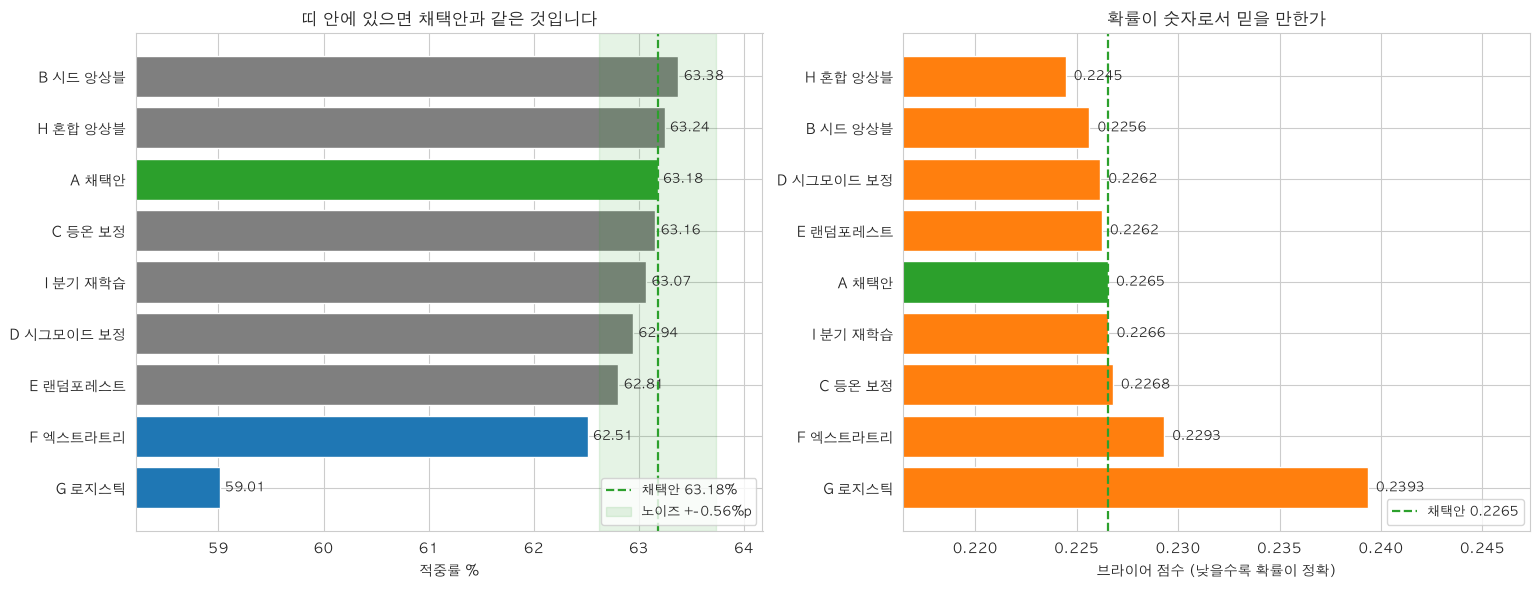

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 6))
s = 표.sort_values("적중률 %")

ax = axes[0]
cols = ["tab:green" if i == "A 채택안" else ("tab:blue" if v else "tab:gray")
        for i, v in zip(s.index, s["노이즈 넘김"])]
ax.barh(s.index, s["적중률 %"], color=cols)
ax.axvline(기준["적중률 %"], color="tab:green", ls="--", lw=1.6,
           label=f"채택안 {기준['적중률 %']:.2f}%")
ax.axvspan(기준["적중률 %"] - FLOOR["적중률 %"], 기준["적중률 %"] + FLOOR["적중률 %"],
           color="tab:green", alpha=0.12, label=f"노이즈 +-{FLOOR['적중률 %']:.2f}%p")
for i, v in enumerate(s["적중률 %"]):
    ax.text(v + 0.05, i, f"{v:.2f}", va="center", fontsize=9)
ax.set_xlim(min(s["적중률 %"]) - 0.8, max(s["적중률 %"]) + 0.8)
ax.set_xlabel("적중률 %")
ax.set_title("띠 안에 있으면 채택안과 같은 것입니다", fontsize=12)
ax.legend(fontsize=9, loc="lower right")

ax = axes[1]
s2 = 표.sort_values("브라이어 점수", ascending=False)
cols = ["tab:green" if i == "A 채택안" else "tab:orange" for i in s2.index]
ax.barh(s2.index, s2["브라이어 점수"], color=cols)
ax.axvline(기준["브라이어 점수"], color="tab:green", ls="--", lw=1.6,
           label=f"채택안 {기준['브라이어 점수']:.4f}")
for i, v in enumerate(s2["브라이어 점수"]):
    ax.text(v + 0.0004, i, f"{v:.4f}", va="center", fontsize=9)
ax.set_xlim(min(s2["브라이어 점수"]) - 0.008, max(s2["브라이어 점수"]) + 0.008)
ax.set_xlabel("브라이어 점수 (낮을수록 확률이 정확)")
ax.set_title("확률이 숫자로서 믿을 만한가", fontsize=12)
ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
plt.show()

## 4. 확률이 믿을 만한가: 신뢰도 곡선

모델이 "70% 오른다"고 한 날 중 **실제로 몇 %가 올랐는지** 그립니다.
대각선에 붙을수록 확률이 정직합니다. 대각선 아래면 자신만만한 것이고,
그러면 임계값이 실제보다 확신 있는 날을 고릅니다.

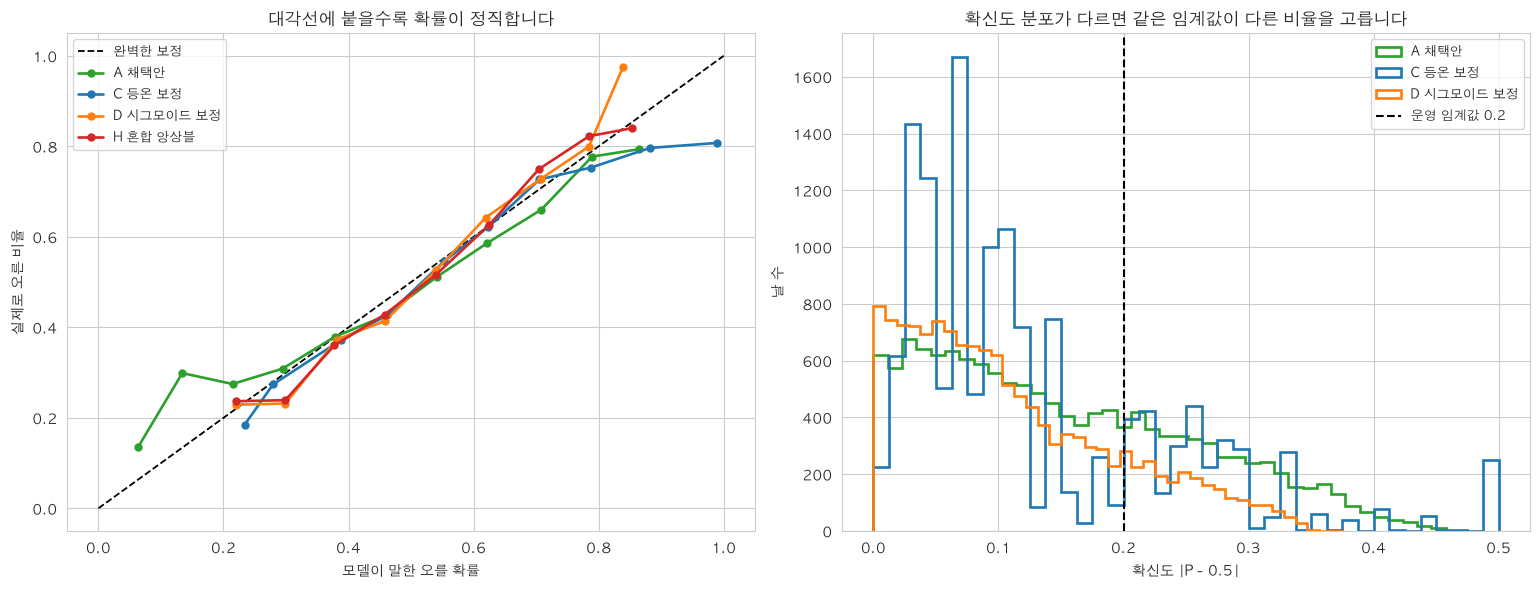

In [7]:
def 신뢰도(r, bins=12):
    b = pd.cut(r.오를확률, np.linspace(0, 1, bins + 1))
    g = r.groupby(b, observed=True).agg(예측=("오를확률", "mean"),
                                        실제=("오름", "mean"), 수=("오름", "size"))
    return g[g.수 >= 40]


fig, axes = plt.subplots(1, 2, figsize=(15.5, 6))

ax = axes[0]
ax.plot([0, 1], [0, 1], color="black", ls="--", lw=1.3, label="완벽한 보정")
for name, col in (("A 채택안", "tab:green"), ("C 등온 보정", "tab:blue"),
                  ("D 시그모이드 보정", "tab:orange"), ("H 혼합 앙상블", "tab:red")):
    g = 신뢰도(결과[name])
    ax.plot(g.예측, g.실제, "o-", color=col, lw=1.9, ms=5, label=name)
ax.set_xlabel("모델이 말한 오를 확률")
ax.set_ylabel("실제로 오른 비율")
ax.set_title("대각선에 붙을수록 확률이 정직합니다", fontsize=12)
ax.legend(fontsize=9)

ax = axes[1]
for name, col in (("A 채택안", "tab:green"), ("C 등온 보정", "tab:blue"),
                  ("D 시그모이드 보정", "tab:orange")):
    ax.hist(결과[name].확신도, bins=40, histtype="step", lw=1.9,
            color=col, label=name)
ax.axvline(CFG.THRESHOLD, color="black", ls="--", lw=1.5,
           label=f"운영 임계값 {CFG.THRESHOLD}")
ax.set_xlabel("확신도 |P - 0.5|")
ax.set_ylabel("날 수")
ax.set_title("확신도 분포가 다르면 같은 임계값이 다른 비율을 고릅니다", fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 5. 커버리지를 맞춘 비교

**여기가 공정한 비교입니다.** 4절 오른쪽 그림처럼 확신도 분포가 후보마다
달라서, 같은 0.20 을 써도 고르는 날의 비율이 다릅니다. 그러면 성능
차이인지 표본 크기 차이인지 못 가립니다(21번에서 16번 결론 일부가
이것 때문에 뒤집혔습니다).

채택안의 커버리지(약 32%)에 맞춰 다시 잽니다.

In [8]:
COV = 기준["확신한 날 비율 %"] / 100
맞춤 = pd.DataFrame({name: score_at_coverage(r, COV, n_items=len(대상))
                     for name, r in 결과.items()}).T
기준m = 맞춤.loc["A 채택안"]
맞춤["확신 적중률 차이 %p"] = 맞춤["확신한 날 적중률 %"] - 기준m["확신한 날 적중률 %"]
맞춤["노이즈 넘김"] = 맞춤["확신 적중률 차이 %p"].abs() > FLOOR["확신한 날 적중률 %"]
display(맞춤.round(3))
print(f"커버리지 {COV*100:.1f}% 로 맞춤 · 노이즈 플로어 "
      f"{FLOOR['확신한 날 적중률 %']:.2f}%p")

,적중률 %,확신한 날 적중률 %,확신한 날 비율 %,더 받은 돈 %,창고비 한도 %,품목당 연 창고행,브라이어 점수,로그손실,확신 적중률 차이 %p,노이즈 넘김
A 채택안,63.179,73.346,31.974,2.695,14.046,45.884,0.227,0.645,0.000,False
B 시드 앙상블,63.377,74.033,31.974,2.765,14.324,46.146,0.226,0.643,0.687,True
C 등온 보정,63.157,73.287,33.768,2.788,13.641,48.877,0.227,0.686,-0.058,False
D 시그모이드 보정,62.945,74.010,31.974,2.549,13.495,45.166,0.226,0.644,0.664,True
E 랜덤포레스트,62.806,73.872,31.974,2.328,12.065,46.129,0.226,0.644,0.527,False
F 엑스트라트리,62.513,73.300,31.974,2.185,12.623,41.385,0.229,0.651,-0.046,False
G 로지스틱,59.013,64.278,31.974,1.054,9.158,27.520,0.239,0.671,-9.068,True
H 혼합 앙상블,63.245,75.086,31.974,2.438,12.759,45.691,0.224,0.640,1.740,True
I 분기 재학습,63.069,73.597,31.974,2.751,14.278,46.076,0.227,0.645,0.252,False


커버리지 32.0% 로 맞춤 · 노이즈 플로어 0.56%p


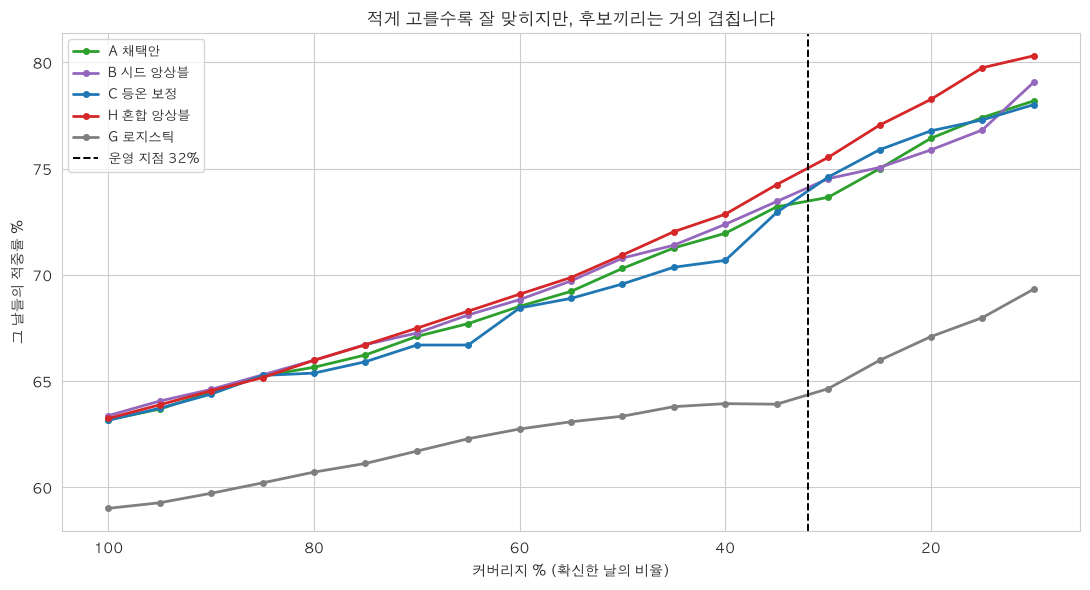

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))
covs = np.round(np.arange(0.10, 1.001, 0.05), 2)
for name, col in (("A 채택안", "tab:green"), ("B 시드 앙상블", "tab:purple"),
                  ("C 등온 보정", "tab:blue"), ("H 혼합 앙상블", "tab:red"),
                  ("G 로지스틱", "tab:gray")):
    ys = [score_at_coverage(결과[name], c, n_items=len(대상))["확신한 날 적중률 %"]
          for c in covs]
    ax.plot(covs * 100, ys, "o-", color=col, lw=2, ms=4, label=name)
ax.axvline(COV * 100, color="black", ls="--", lw=1.4,
           label=f"운영 지점 {COV*100:.0f}%")
ax.set_xlabel("커버리지 % (확신한 날의 비율)")
ax.set_ylabel("그 날들의 적중률 %")
ax.set_title("적게 고를수록 잘 맞히지만, 후보끼리는 거의 겹칩니다", fontsize=12)
ax.legend(fontsize=9)
ax.invert_xaxis()
plt.tight_layout()
plt.show()

## 6. 폴드별 안정성

27번에서 배운 것: **묶어서 좋아 보여도 폴드로 쪼개면 무너질 수 있습니다.**
후보별로 폴드마다 적중률을 재서 흔들림을 봅니다.

In [10]:
폴드별 = pd.DataFrame({name: r.groupby("fold").방향맞음.mean() * 100
                       for name, r in 결과.items()})
display(폴드별.round(2))
안정 = pd.DataFrame({
    "폴드 평균": 폴드별.mean(),
    "폴드 표준편차": 폴드별.std(),
    "채택안보다 나은 폴드": (폴드별.sub(폴드별["A 채택안"], axis=0) > 0).sum(),
})
display(안정.round(2))
print(f"폴드 {len(폴드별)}개 중 몇 번 이겼는지가 핵심입니다.")
print("4/7 은 동전 던지기와 구별되지 않습니다.")

,A 채택안,B 시드 앙상블,C 등온 보정,D 시그모이드 보정,E 랜덤포레스트,F 엑스트라트리,G 로지스틱,H 혼합 앙상블,I 분기 재학습
fold,,,,,,,,,
2023-01,57.22,57.96,56.54,58.02,57.68,59.22,57.51,57.22,57.22
2023-07,58.93,59.55,59.35,59.40,60.18,60.18,55.19,59.55,58.36
2024-01,62.11,62.63,63.31,62.42,62.06,60.50,53.79,62.06,61.38
2024-07,68.09,67.06,67.32,68.24,68.14,66.96,61.66,67.94,68.19
2025-01,63.72,64.19,64.09,63.51,63.45,65.10,63.56,64.83,64.30
2025-07,65.37,65.17,65.27,65.17,64.06,63.00,57.06,64.97,65.78
2026-01,65.77,66.09,65.23,63.27,63.45,62.37,63.58,65.23,65.28


,폴드 평균,폴드 표준편차,채택안보다 나은 폴드
A 채택안,63.03,3.88,0
B 시드 앙상블,63.24,3.39,5
C 등온 보정,63.02,3.77,3
D 시그모이드 보정,62.86,3.43,4
E 랜덤포레스트,62.72,3.28,3
F 엑스트라트리,62.47,2.80,3
G 로지스틱,58.91,4.01,1
H 혼합 앙상블,63.12,3.71,2
I 분기 재학습,62.93,4.06,3


폴드 7개 중 몇 번 이겼는지가 핵심입니다.
4/7 은 동전 던지기와 구별되지 않습니다.


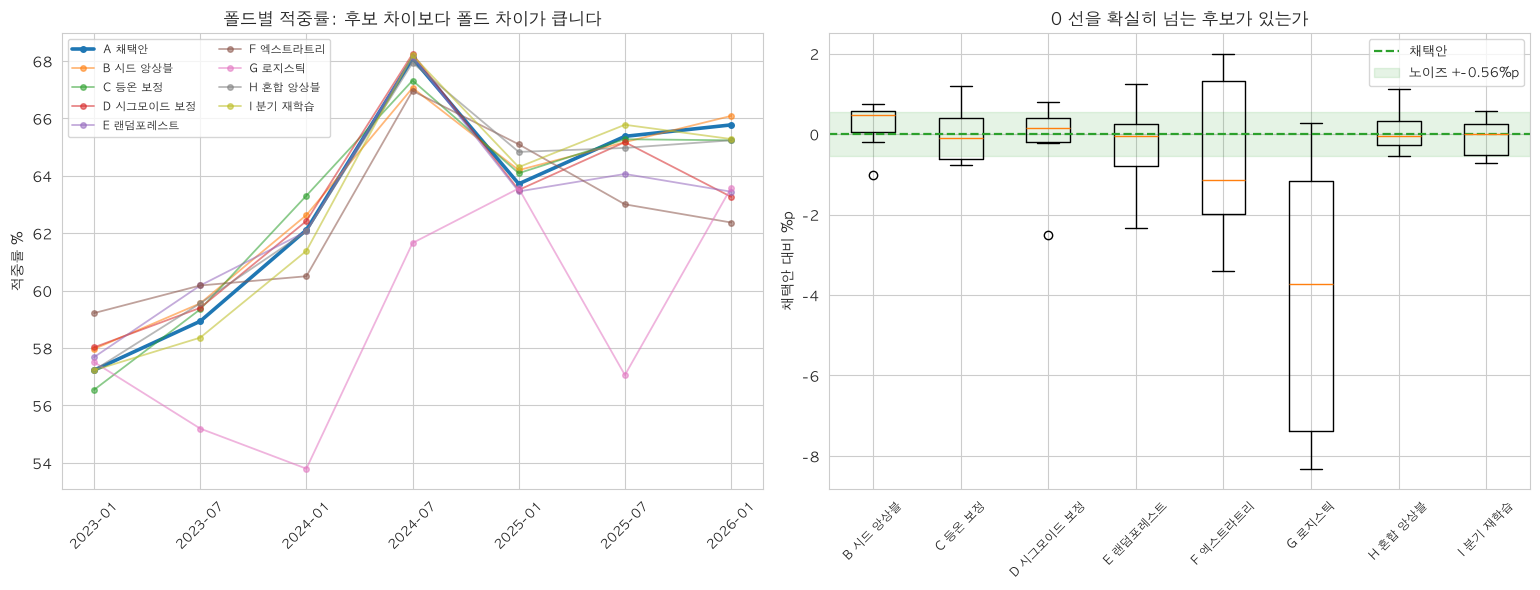

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 6))

ax = axes[0]
for name in 폴드별.columns:
    lw, a = (2.6, 1.0) if name == "A 채택안" else (1.3, 0.55)
    ax.plot(폴드별.index, 폴드별[name], "o-", lw=lw, ms=4, alpha=a, label=name)
ax.set_ylabel("적중률 %")
ax.set_title("폴드별 적중률: 후보 차이보다 폴드 차이가 큽니다", fontsize=12)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.legend(fontsize=8, ncol=2)

ax = axes[1]
d = 폴드별.sub(폴드별["A 채택안"], axis=0).drop(columns="A 채택안")
ax.boxplot([d[c] for c in d.columns], tick_labels=list(d.columns))
ax.axhline(0, color="tab:green", ls="--", lw=1.6, label="채택안")
ax.axhspan(-FLOOR["적중률 %"], FLOOR["적중률 %"], color="tab:green", alpha=0.12,
           label=f"노이즈 +-{FLOOR['적중률 %']:.2f}%p")
ax.set_ylabel("채택안 대비 %p")
ax.set_title("0 선을 확실히 넘는 후보가 있는가", fontsize=12)
ax.tick_params(axis="x", rotation=45, labelsize=8.5)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 7. 돈으로 환산하면

적중률 몇 %p 는 손에 안 잡힙니다. 창고 후보 11품목 기준으로 1,000만
원어치를 출하했을 때 얼마를 더 버는지로 바꿉니다.

In [12]:
창고 = GROUPS["창고 후보"]
rows = []
for name, r in 결과.items():
    sub = r[r.item.isin(창고)].reset_index(drop=True)
    sc = score_at_coverage(sub, COV, n_items=len(창고))
    rows.append({"후보": name, "적중률 %": sc["적중률 %"],
                 "더 받은 돈 %": sc["더 받은 돈 %"],
                 "창고비 한도 %": sc["창고비 한도 %"],
                 "1,000만 원당 더 번 돈 (만원)": 1000 * sc["더 받은 돈 %"] / 100})
돈 = pd.DataFrame(rows).set_index("후보").sort_values("1,000만 원당 더 번 돈 (만원)")
display(돈.round(2))
print(f"창고 후보 {len(창고)}품목 · 커버리지 {COV*100:.1f}% 맞춤")

,적중률 %,더 받은 돈 %,창고비 한도 %,"1,000만 원당 더 번 돈 (만원)"
후보,,,,
G 로지스틱,58.58,1.36,11.68,13.61
D 시그모이드 보정,62.54,1.99,11.32,19.89
C 등온 보정,62.78,2.05,11.07,20.53
F 엑스트라트리,61.95,2.08,12.13,20.77
E 랜덤포레스트,62.68,2.12,11.14,21.16
H 혼합 앙상블,62.87,2.22,11.97,22.19
I 분기 재학습,62.71,2.33,12.33,23.30
B 시드 앙상블,63.01,2.42,13.02,24.25
A 채택안,63.00,2.44,13.04,24.44


창고 후보 11품목 · 커버리지 32.0% 맞춤


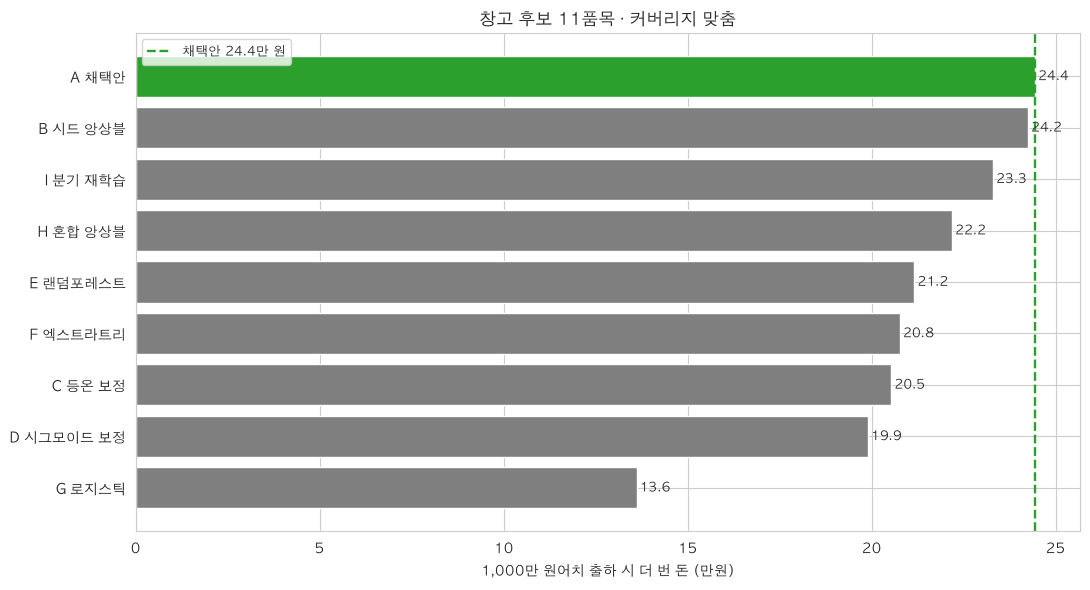

In [13]:
fig, ax = plt.subplots(figsize=(11, 6))
base = 돈.loc["A 채택안", "1,000만 원당 더 번 돈 (만원)"]
cols = ["tab:green" if i == "A 채택안" else ("tab:blue" if v > base else "tab:gray")
        for i, v in zip(돈.index, 돈["1,000만 원당 더 번 돈 (만원)"])]
ax.barh(돈.index, 돈["1,000만 원당 더 번 돈 (만원)"], color=cols)
ax.axvline(base, color="tab:green", ls="--", lw=1.7, label=f"채택안 {base:.1f}만 원")
for i, v in enumerate(돈["1,000만 원당 더 번 돈 (만원)"]):
    ax.text(v + 0.08, i, f"{v:.1f}", va="center", fontsize=9.5)
ax.set_xlabel("1,000만 원어치 출하 시 더 번 돈 (만원)")
ax.set_title("창고 후보 11품목 · 커버리지 맞춤", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8. 정리

### 한 줄 요약

**채택안을 유지합니다.** 후보 8개 중 어느 것도 판정 규칙 셋을 다 통과하지
못했습니다. **지금 피처로는 여기가 최대입니다.**

### 판정

| 후보 | ①노이즈 넘김 | ②폴드 일관성 | ③돈 | 판정 |
|---|---|---|---|---|
| **A 채택안** | 기준 | 기준 | **24.44만 원** | **유지** |
| B 시드 앙상블 | +0.69%p (넘김) | **5/7** | 24.25만 원 | 아깝게 탈락 |
| C 등온 보정 | -0.06%p | 3/7 | 20.53만 원 | 탈락 |
| D 시그모이드 보정 | +0.66%p (넘김) | 4/7 | 19.89만 원 | 탈락 |
| E 랜덤포레스트 | +0.53%p | 3/7 | 21.16만 원 | 탈락 |
| F 엑스트라트리 | -0.05%p | 3/7 | 20.77만 원 | 탈락 |
| G 로지스틱 | **-9.07%p** | 1/7 | 13.61만 원 | 탈락 |
| H 혼합 앙상블 | **+1.74%p** (넘김) | **2/7** | 22.19만 원 | **함정** |
| I 분기 재학습 | +0.25%p | 3/7 | 23.30만 원 | 탈락 |

노이즈 플로어는 0.56%p 입니다. 커버리지 32.0% 로 맞춘 뒤 잰 값입니다.

### H 혼합 앙상블이 함정인 이유

**확신한 날 적중률이 +1.74%p 로 가장 높은데, 채택하면 안 됩니다.**

- **폴드 7개 중 2개에서만 이깁니다.** 동전 던지기보다 나쁩니다.
- **돈은 오히려 2.25만 원 적습니다**(22.19 vs 24.44).

적중률이 올랐는데 돈이 줄었다는 건, **맞힌 날의 가격 변동 폭이 작았다**는
뜻입니다. 자주 맞히지만 잔챙이를 맞히는 것이라 매출로 안 이어집니다.

27번에서 배운 걸 그대로 다시 만났습니다: **묶어서 좋아 보여도 폴드로
쪼개면 무너집니다.** 지표 하나만 보고 채택했으면 성능이 나빠졌을 것입니다.

### B 시드 앙상블은 아깝지만 뺍니다

**셋 중 둘을 통과한 유일한 후보입니다** — 노이즈를 넘었고(+0.69%p)
폴드 5/7 로 일관됩니다. 폴드 표준편차도 3.39 로 채택안(3.88)보다 안정적입니다.

**그런데 돈이 0.19만 원 적고, 학습이 5배 느립니다**(62초 vs 12초).
+0.69%p 는 노이즈 0.56%p 를 겨우 0.13%p 넘긴 값이라 확실한 개선이라
부르기 어렵습니다. **비용 대비 근거가 약해 뺍니다.**

돌아올 여지는 남깁니다: 데이터가 더 쌓여 노이즈 플로어가 좁아지면
그때는 진짜 개선으로 보일 수 있습니다.

### 확률은 이미 잘 보정돼 있었습니다

이 문서의 주 가설이었는데 **기각됐습니다.**

| 후보 | 브라이어 점수 | 로그손실 |
|---|---|---|
| A 채택안 | 0.227 | 0.645 |
| C 등온 보정 | 0.227 | **0.686 (악화)** |
| D 시그모이드 보정 | 0.226 | 0.644 |
| H 혼합 앙상블 | **0.224** | **0.640** |

보정을 걸어도 브라이어가 0.227 → 0.226~0.227 로 사실상 그대로이고,
등온 보정은 로그손실이 오히려 나빠졌습니다(과적합). 신뢰도 곡선도
채택안이 이미 대각선을 잘 따릅니다.

**즉 `HistGradientBoosting` 의 확률은 손댈 필요가 없었습니다.**
운영 임계값 0.20 은 믿을 만한 숫자 위에 서 있습니다.

### 선형으로는 안 됩니다

**G 로지스틱이 59.01% 로 유일하게 크게 뒤집니다**(채택안 63.18%).
4.17%p 차이는 노이즈의 7배입니다. 가격 방향에는 **비선형 상호작용이
실제로 있고**, 트리 계열이 그걸 잡고 있다는 뜻입니다.

역으로 읽으면 **좋은 소식**입니다: 모델이 단순 추세 추종이 아니라
피처 조합을 쓰고 있습니다.

### 재학습 주기는 반년으로 충분합니다

**I 분기 재학습이 +0.25%p 로 노이즈 안쪽**입니다. 3개월마다 다시
학습해도 반년마다 하는 것과 구별되지 않습니다. 운영 부담을 줄이는 쪽으로
읽으면 됩니다 — **반년에 한 번이면 됩니다.**

### 폴드 차이가 후보 차이보다 큽니다

가장 눈에 띄는 사실입니다. 후보끼리는 1%p 안쪽인데 **폴드끼리는
57.2%(2023-01) ~ 68.1%(2024-07) 로 11%p 벌어집니다.**

**모델을 바꾸는 것보다 시기가 훨씬 중요합니다.** 2023 상반기처럼 어려운
반년에는 무슨 모델을 써도 57~59% 입니다. 이건 모델의 한계가 아니라
**그 시기 가격이 예측하기 어려웠다**는 뜻입니다.

운영에 주는 함의: **성적이 떨어져도 바로 모델을 의심하지 마세요.**
시기 탓일 수 있고, 반년 단위로 봐야 판단이 섭니다.

### 그래서 최종 사양

```python
HistGradientBoostingClassifier(
    learning_rate=0.014, max_iter=502, min_samples_leaf=21,
    max_leaf_nodes=15, l2_regularization=1.0,
    early_stopping=False, random_state=42)
# 피처 21개 · 19품목 학습 · 운영 16품목 · 확신도 임계값 0.20
# 재학습 반년 · 보정 없음 · 앙상블 없음
```

`model/config.py` 에 이미 들어 있는 값 그대로입니다. **바꿀 것이 없다는
게 이 문서의 결론입니다.**

### 한계

- **후보 8개가 전부는 아닙니다.** XGBoost·LightGBM·CatBoost 는 안 봤고,
  신경망 계열도 안 봤습니다. 다만 05번에서 모델 용량이 병목이 아니라고
  나왔고 여기서 계열을 셋 바꿔도 차이가 없었으니, **다른 부스팅 구현이
  판을 뒤집을 가능성은 낮습니다.**
- **커버리지 32% 한 지점에서만 비교했습니다.** 5절 곡선을 보면 다른
  커버리지에서도 후보들이 겹치지만, 각 지점에서 노이즈 판정을 다시
  하지는 않았습니다.
- **노이즈 플로어는 시드 5개로 쟀습니다.** 더 많이 돌리면 폭이 넓어질
  수 있고, 그러면 B 시드 앙상블의 +0.69%p 도 묻힙니다.
- **돈 지표는 창고 후보 11품목 기준**입니다. 중간지대 4품목으로 좁히면
  순위가 달라질 수 있는데 확인 안 했습니다.

### 다음

**모델링은 여기서 닫습니다.** 남은 것은 운영입니다.

1. **일 단위 추론** — 매일 마트를 갱신하고 확률을 냅니다
2. **임계 적용** — 확신도 0.20 이상인 날만 신호
3. **성적 모니터링** — 7거래일 뒤 실측과 대조. **반년 단위로 봅니다**
   (폴드 차이가 11%p 라 한 달 성적으로는 판단이 안 섭니다)
4. **재학습** — 반년에 한 번

성적이 떨어지면 **모델보다 데이터를 먼저 의심합니다.** 원천 갱신이
멈췄는지(생강이 그랬습니다), 마트 행 수가 줄었는지 먼저 봅니다.